In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from lightgbm import LGBMClassifier
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
# 데이터 로드

df = pd.read_csv('data/hotel_bookings.csv')

print("=== DATA LOADING ===\n")
print(df.shape)
df.head()

=== DATA LOADING ===

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# 결측치 확인

df.isnull().sum()[df.isnull().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [48]:
# 데이터 클리닝 - 결측치 및 이상치 처리

# country : 최빈값으로 대체
mfc = df['country']. mode()[0]
df['country'] = df['country'].fillna(mfc)

# children : 0으로 대체 및 정수형 변환
df['children'] = df['children'].fillna(0).astype(int)

# adr : 극단적인 이상치 제거 ($5000 초과), 음수 값 처리 ($0 이상, $0은 프로모션일 수 있으므로)
df = df[df['adr'] <= 5000].copy()
df['adr'] = df['adr'].apply(lambda x: x if x >= 0 else 0)

# 투숙객이 0인 비정상 데이터 제거
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df = df[df['total_guests'] > 0].copy()
df = df.drop('total_guests', axis=1)

In [49]:
# 데이터 가공

# 가족 여행 여부 (Adults >= 1 and (children or babies >= 1))
df['is_family'] = np.where((df['adults'] >= 1) & (df['children'] + df['babies'] >= 1), 1, 0)

# 리드타임 5개 범위로 구분
# 1개월 미만 : 0~29, 1~3개월: 30-89, 3~6개월: 90~179, 6~12개월: 180~364, 12개월 이상: 365~
bins = [0, 30, 90, 180, 365, df['lead_time'].max() + 1]
labels = ['<1 month', '1-3 months', '3-6 months', '6-12 months', '>=12 months']
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins = bins,
    labels= labels,
    right=False,
    include_lowest=True
)

# 국가 빈도수 top 10 + Others로 분류
top_10_countries = df['country'].value_counts().nlargest(10).index
df['country_grouped'] = df['country'].apply(lambda x: x if x in top_10_countries else 'Others')

In [78]:
# 모델링에 사용할 최종 컬럼

used_cols = [
    'is_canceled',
    'hotel',
    'is_family',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'deposit_type',
    'customer_type',
    'lead_time_group',
    'country_grouped',
    'adr',
    'booking_changes',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

df_filtered = df[used_cols].copy()

In [79]:
# 인코딩

# One-Hot Encoding이 필요한 범주형 컬럼 목록
cate_cols = [
    'hotel', 
    'deposit_type', 
    'customer_type',
    'lead_time_group', 
    'country_grouped'
]

# One-Hot Encoding 적용 
df_final = pd.get_dummies(
    df_filtered,
    columns=cate_cols,
    drop_first=True         # 다중공선성 방지
)

df_final.head(2).T

,0,1
is_canceled,0,0
is_family,0,0
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
is_repeated_guest,0,0
previous_cancellations,0,0
previous_bookings_not_canceled,0,0
adr,0.0,0.0
booking_changes,3,4
required_car_parking_spaces,0,0


In [80]:
# 데이터셋 분리 

X = df_final.drop('is_canceled', axis=1)
y = df_final['is_canceled']

X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (95367, 30)
X_test shape: (23842, 30)


In [81]:
# 데이터 스케일링

model_performance = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
# 모델링

# Logistic Regression 학습
lr = LogisticRegression(random_state=42, solver='liblinear')
lr.fit(X_train_scaled, y_train)
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)
model_performance['Logistic Regressing'] = {
    'AUC-ROC': roc_auc_score(y_test, lr_pred_proba), 
    'Recall': recall_score(y_test, lr_pred),
    'F1-Score': f1_score(y_test, lr_pred)
}

# LightGBM 학습
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm.predict(X_test)
model_performance['LightGBM'] = {
    'AUC-ROC': roc_auc_score(y_test, lgbm_pred_proba), 
    'Recall': recall_score(y_test, lgbm_pred), 
    'F1-Score': f1_score(y_test, lgbm_pred)
}

# keras 학습
input_dim = X_train_scaled.shape[1]
model = Sequential([
    Input(shape=(input_dim,)),
          Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'recall']
)
model.fit(X_train_scaled,
          y_train,
          epochs=10,
          batch_size=32,
          validation_split=0.1,
          verbose=0
)
dl_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
dl_pred = (dl_pred_proba > 0.5).astype(int)
model_performance['Deep Learning (Keras)'] = {
    'AUC-ROC': roc_auc_score(y_test, dl_pred_proba), 
    'Recall': recall_score(y_test, dl_pred), 
    'F1-Score': f1_score(y_test, dl_pred)
}

In [83]:
result_df = pd.DataFrame(model_performance).T
print("\n=== 모델 성능 비교 ===")
print(result_df.sort_values(by='AUC-ROC', ascending=False).round(4))


=== 모델 성능 비교 ===
                       AUC-ROC  Recall  F1-Score
LightGBM                0.9057  0.6916    0.7535
Deep Learning (Keras)   0.8984  0.6882    0.7448
Logistic Regressing     0.8674  0.5899    0.6843


In [39]:
# 최종 선정 모델 - 변수 중요도

feature_imp = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("=== LightGBM 변수 중요도(취소 예측 영향 Top 10) ===\n")
print(feature_imp.head(10))

=== LightGBM 변수 중요도(취소 예측 영향 Top 10) ===

adr                               1126
stays_in_week_nights               349
stays_in_weekend_nights            198
hotel_Resort Hotel                 153
country_grouped_PRT                143
booking_changes                    136
customer_type_Transient            124
customer_type_Transient-Party      123
previous_bookings_not_canceled     119
previous_cancellations              88
dtype: int32


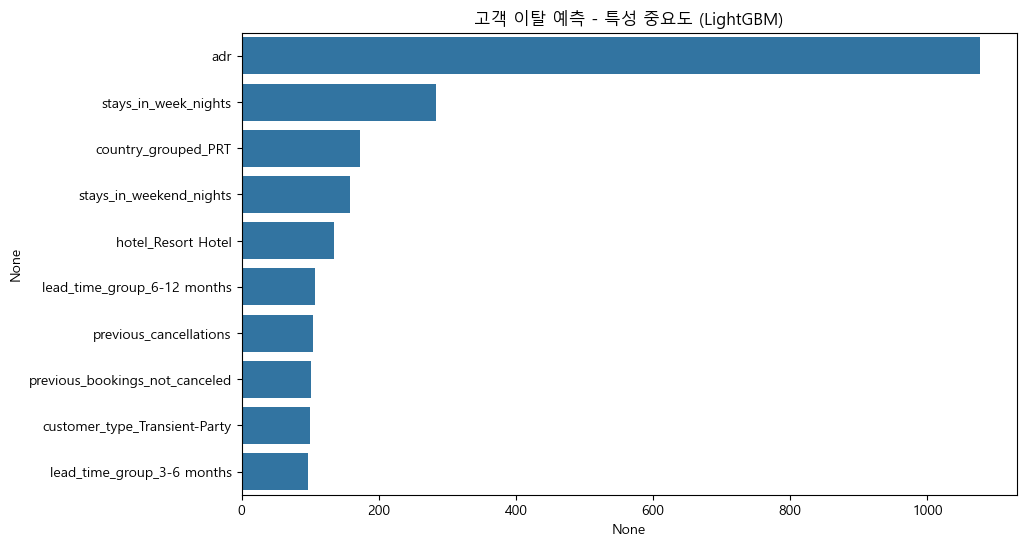

In [14]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index)
plt.title('고객 이탈 예측 - 특성 중요도 (LightGBM)')
plt.show()